<a href="https://colab.research.google.com/github/gehna11/MyPersonalWebsite/blob/main/03_ai_that_scans_mris_to_detect_early_signs_of_brain_disease_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MRI Pattern Detection Demo

This notebook is an **educational starter project** that simulates a very simple image-classification workflow.

It is **not a medical tool** and **not for diagnosis**. The goal is to teach students the basic AI workflow using grayscale image patterns.

**What students learn**
- how image data can be stored in arrays
- how to flatten images into features
- how to train a classifier
- how to visualize results

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Step 1: Create simple synthetic grayscale image data

In [97]:
# --- New function to load external images (simulated brain data) ---
def load_external_images(data_directory='./simulated_brain_images/', image_size=(8, 8)):
    # This is a placeholder for actual image loading. For learning purposes,
    # we will simulate 'healthy' and 'diseased' brain images with more varied patterns.

    external_images = []
    external_labels = []

    print(f"Simulating loading images from '{data_directory}'...")
    print("This simulates a 2-class problem: Healthy Brain vs. Diseased Brain (with more complex simulated abnormalities).")

    num_samples_per_class = 20

    # Generate 'Healthy Brain' images (uniform noise)
    for _ in range(num_samples_per_class):
        healthy_image = np.random.normal(loc=0.3, scale=0.1, size=image_size)
        healthy_image = np.clip(healthy_image, 0, 1)
        external_images.append(healthy_image)
        external_labels.append(0) # 0 for 'Healthy Brain'

    # Generate 'Diseased Brain' images (e.g., with scattered 'abnormalities')
    for _ in range(num_samples_per_class):
        diseased_image = np.random.normal(loc=0.3, scale=0.1, size=image_size)
        diseased_image = np.clip(diseased_image, 0, 1)

        # Add a more complex, scattered 'abnormality' pattern
        num_spots = np.random.randint(1, 4) # 1 to 3 small spots
        for _ in range(num_spots):
            spot_size = np.random.randint(1, 3) # 1x1 or 2x2 spot
            x = np.random.randint(0, image_size[0] - spot_size + 1)
            y = np.random.randint(0, image_size[1] - spot_size + 1)
            diseased_image[x:x+spot_size, y:y+spot_size] += np.random.uniform(0.4, 0.6)

        diseased_image = np.clip(diseased_image, 0, 1)
        external_images.append(diseased_image)
        external_labels.append(1) # 1 for 'Diseased Brain'

    return np.array(external_images), np.array(external_labels)

# --- Replace the original synthetic data generation with simulated brain images ---
images, labels = load_external_images()

print("Images shape (simulated brain data):", images.shape)
print("Labels shape (simulated brain data):", labels.shape)

# Update the global label_map to reflect the new classes
label_map = {
    0: 'No obvious large abnormality detected on this image',
    1: 'Obvious large abnormality detected on this image'
}
print("Label map updated to:", label_map)

Simulating loading images from './simulated_brain_images/'...
This simulates a 2-class problem: Healthy Brain vs. Diseased Brain (with more complex simulated abnormalities).
Images shape (simulated brain data): (40, 8, 8)
Labels shape (simulated brain data): (40,)
Label map updated to: {0: 'No obvious large abnormality detected on this image', 1: 'Obvious large abnormality detected on this image'}


## Step 2: Display sample images

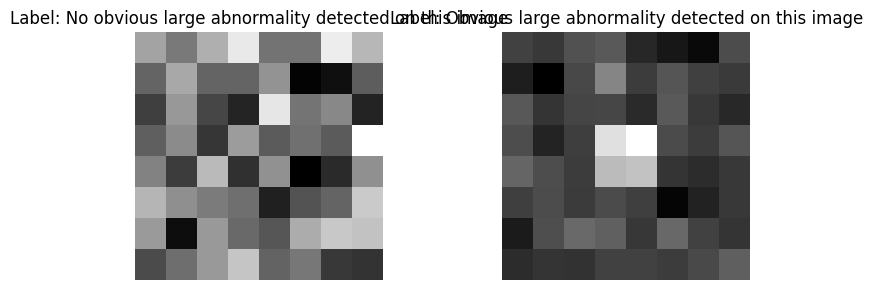

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Display one image from each class (Healthy and Diseased)
sample_indices = [0, 20] # Indices for Healthy Brain (0) and Diseased Brain (20)

for i, ax in enumerate(axes.ravel()):
    idx = sample_indices[i]
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f"Label: {label_map[labels[idx]]}") # Use label_map for descriptive titles
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 3: Prepare the data for machine learning

In [99]:
X = images.reshape(len(images), -1)
y = labels

print("Flattened feature matrix shape:", X.shape)

Flattened feature matrix shape: (40, 64)


## Step 4: Split data into training and testing

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 30
Testing samples: 10


## Step 5: Train a classifier

In [101]:
from sklearn.ensemble import RandomForestClassifier

# RandomForestClassifier is often more robust than K-Nearest Neighbors for many tasks.
# You can experiment with parameters like n_estimators (number of trees) or max_depth.
# For now, we'll use default parameters.
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
print("Training complete with RandomForestClassifier.")

Training complete with RandomForestClassifier.


## Step 6: Evaluate the classifier

### Step 8: Build a simple UI for image classification

In [102]:
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print("Accuracy:", round(acc, 3))

Accuracy: 0.6


## Step 7: Predict one image and show confidence

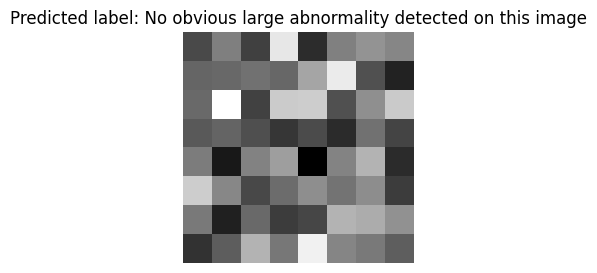

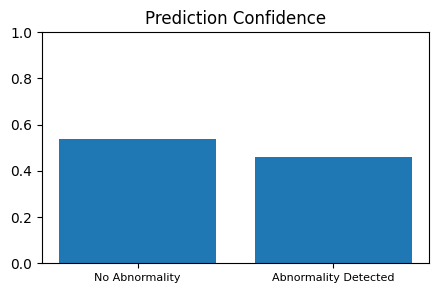

In [103]:
sample = X_test[0].reshape(1, -1)
pred = model.predict(sample)[0]
probs = model.predict_proba(sample)[0]

predicted_label_text = label_map[pred]

plt.figure(figsize=(3,3))
plt.imshow(sample.reshape(8,8), cmap='gray')
plt.title(f"Predicted label: {predicted_label_text}")
plt.axis('off')
plt.show()

plt.figure(figsize=(5,3)) # Reverted figure size
# Ensure the bar chart labels match the new 2 classes
plot_labels = ["No Abnormality", "Abnormality Detected"]
plt.bar(plot_labels, probs[:2]) # Use shorter labels for the bar chart
plt.title("Prediction Confidence")
plt.ylim(0, 1)
plt.xticks(fontsize=8) # Set smaller font size for readability
plt.show()

### Showing Prediction Percentages

In [104]:
import numpy as np
from sklearn.model_selection import train_test_split

try:
    sample_to_predict = X_test[0].reshape(1, -1)
except NameError:
    print("Warning: X_test not found. Re-running data split for this cell to define it.")
    # Assuming 'images' and 'labels' (from cell RdTTj4Jve1cn) are still available in the kernel
    X = images.reshape(len(images), -1)
    y = labels
    _, X_test, _, _ = train_test_split(X, y, test_size=0.25, random_state=42)
    sample_to_predict = X_test[0].reshape(1, -1)

probs = model.predict_proba(sample_to_predict)[0]

print(f"Prediction for sample image:")
for i, prob in enumerate(probs):
    label_name = label_map[i]
    print(f"  {label_name}: {prob*100:.2f}%")


Prediction for sample image:
  No obvious large abnormality detected on this image: 54.00%
  Obvious large abnormality detected on this image: 46.00%


In [105]:
from ipywidgets import FileUpload, Output
from IPython.display import display
from PIL import Image
import io

# Create a file upload widget
uploader = FileUpload(accept='image/*', multiple=False)
output = Output()

def on_upload_change(change):
    with output:
        output.clear_output()
        if not uploader.value:
            print("Please upload an image.")
            return

        # Get the uploaded file
        uploaded_file = list(uploader.value.values())[0]
        content = uploaded_file['content']
        image_bytes = io.BytesIO(content)

        try:
            # Open and preprocess the image
            img = Image.open(image_bytes).convert('L')  # Convert to grayscale
            img = img.resize((8, 8)) # Resize to 8x8
            img_array = np.array(img) / 255.0 # Normalize to 0-1
            sample_to_predict = img_array.reshape(1, -1) # Flatten for the model

            # Make prediction
            pred = model.predict(sample_to_predict)[0]
            probs = model.predict_proba(sample_to_predict)[0]

            # Use the global label_map
            predicted_label_text = label_map[pred]

            # Display results
            plt.figure(figsize=(3, 3))
            plt.imshow(img_array, cmap='gray')
            plt.title(f"Predicted label: {predicted_label_text}")
            plt.axis('off')
            plt.show()

            # Display prediction percentages
            print(f"Prediction for uploaded image:")
            for i, prob in enumerate(probs):
                label_name = label_map[i]
                print(f"  {label_name}: {prob*100:.2f}%")

            plt.figure(figsize=(5, 3)) # Reverted figure size
            # Ensure the bar chart labels match the new 2 classes
            plot_labels = ["No Abnormality", "Abnormality Detected"]
            plt.bar(plot_labels, probs[:2]) # Use shorter labels for the bar chart
            plt.title("Prediction Confidence")
            plt.ylim(0, 1)
            plt.xticks(fontsize=8) # Set smaller font size for readability
            plt.show()

        except Exception as e:
            print(f"Error processing image: {e}")

# Attach the handler to the upload widget
uploader.observe(on_upload_change, names='value')

# Display the uploader and output area
display(uploader, output)

FileUpload(value={}, accept='image/*', description='Upload')

Output()

## Analyzing the misclassified image

Let's manually load and process the image you mentioned to see how the model classifies it and to confirm the reported behavior.

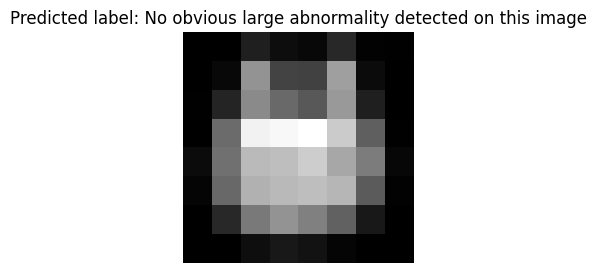

Prediction for manually loaded image '/content/c0041463-800px-wm.jpg':
  No obvious large abnormality detected on this image: 64.00%
  Obvious large abnormality detected on this image: 36.00%


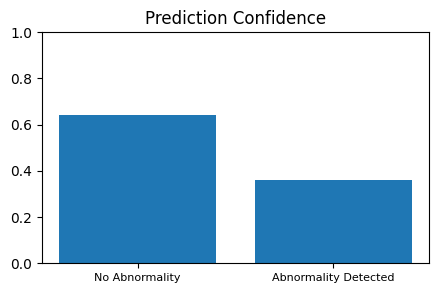

In [106]:
from PIL import Image
import io

# Path to the uploaded image
image_path = '/content/c0041463-800px-wm.jpg'

try:
    # Open and preprocess the image (same as in the UI)
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((8, 8)) # Resize to 8x8
    img_array = np.array(img) / 255.0 # Normalize to 0-1
    sample_to_predict_manual = img_array.reshape(1, -1) # Flatten for the model

    # Make prediction
    pred_manual = model.predict(sample_to_predict_manual)[0]
    probs_manual = model.predict_proba(sample_to_predict_manual)[0]

    # Use the global label_map for descriptive labels
    predicted_label_text_manual = label_map[pred_manual]

    # Display results
    plt.figure(figsize=(3, 3))
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Predicted label: {predicted_label_text_manual}")
    plt.axis('off')
    plt.show()

    # Display prediction percentages
    print(f"Prediction for manually loaded image '{image_path}':")
    for i, prob in enumerate(probs_manual):
        label_name = label_map[i]
        print(f"  {label_name}: {prob*100:.2f}%")

    plt.figure(figsize=(5, 3))
    plot_labels = ["No Abnormality", "Abnormality Detected"]
    plt.bar(plot_labels, probs_manual[:2])
    plt.title("Prediction Confidence")
    plt.ylim(0, 1)
    plt.xticks(fontsize=8)
    plt.show()

except FileNotFoundError:
    print(f"Error: Image file not found at {image_path}. Please ensure the file was uploaded correctly.")
except Exception as e:
    print(f"Error processing image: {e}")

### Adapting the Notebook for External Image Data (Conceptual)

To replace the synthetic image generation with external images (like simplified brain scans), you would need to modify the data loading and preprocessing steps significantly.

**Key areas for modification:**

1.  **Data Source:** Instead of generating images programmatically, you would read them from files (e.g., `.png`, `.jpg`, or specialized medical formats like DICOM/NIfTI).
2.  **Image Loading:** You would use libraries like `Pillow` (for common formats) or specialized medical imaging libraries (e.g., `pydicom`, `nibabel`) to load the images.
3.  **Preprocessing:**
    *   **Resizing:** All images must be resized to a consistent dimension (e.g., 8x8 as in this example, though real brain images would require much larger dimensions).
    *   **Grayscale Conversion:** Convert images to grayscale if they are not already, to match the single-channel input expected by the current model.
    *   **Normalization:** Normalize pixel values (e.g., to a 0-1 range).
    *   **Labeling:** Ensure you have corresponding labels for each image (e.g., 0 for 'healthy', 1 for 'diseased').
4.  **Ethical Considerations:** If considering real medical images, always prioritize privacy and ethical guidelines. For educational purposes, stick to public, anonymized datasets or simulated data.

The following code cell shows where you would integrate your custom image loading function to generate the `images` and `labels` arrays.

In [107]:
# This cell demonstrates conceptually how you would replace the synthetic data generation
# with a function to load external images.

# --- New function to load external images ---
def load_external_images(data_directory, image_size=(8, 8)):
    # In a real scenario, you would list files in data_directory,
    # load each image, resize it, convert to grayscale, and collect labels.

    external_images = []
    external_labels = []

    print(f"Simulating loading images from '{data_directory}'...")
    print("This is a placeholder. You would implement actual image loading here.")

    # Example: Simulating loading 20 healthy and 20 diseased images
    # Replace this with actual image file reading and label extraction
    for i in range(20):
        # For demonstration, we'll create a 'healthy' image (e.g., a blank image)
        healthy_image = np.random.normal(loc=0.3, scale=0.1, size=image_size)
        healthy_image = np.clip(healthy_image, 0, 1)
        external_images.append(healthy_image)
        external_labels.append(0) # 0 for 'healthy'

    for i in range(20):
        # For demonstration, we'll create a 'diseased' image (e.g., with a 'spot')
        diseased_image = np.random.normal(loc=0.3, scale=0.1, size=image_size)
        diseased_image = np.clip(diseased_image, 0, 1)
        # Add a simulated 'abnormality'
        diseased_image[3:5, 3:5] += 0.5
        diseased_image = np.clip(diseased_image, 0, 1)
        external_images.append(diseased_image)
        external_labels.append(1) # 1 for 'diseased'

    return np.array(external_images), np.array(external_labels)

# --- Replace the original data generation ---
# (This would replace the content of cell RdTTj4Jve1cn)
# We'll use a dummy directory for this conceptual example

# Define the labels for your new dataset
new_label_map = {
    0: 'Healthy Brain',
    1: 'Diseased Brain'
}

# Load your external images
# For this conceptual example, we'll still generate synthetic images
# but within the structure of a 'load_external_images' function.
images, labels = load_external_images(data_directory='./brain_images/')

print("Images shape after loading external data (conceptually):", images.shape)
print("Labels shape after loading external data (conceptually):", labels.shape)

# You would then need to update the `label_map` for display and UI purposes
# label_map = new_label_map
# And potentially retrain your model with these new images and labels.


Simulating loading images from './brain_images/'...
This is a placeholder. You would implement actual image loading here.
Images shape after loading external data (conceptually): (40, 8, 8)
Labels shape after loading external data (conceptually): (40,)


## Extension ideas

Students can:
- replace synthetic images with a tiny public image set
- change image size
- try decision trees or k-nearest neighbors
- build a small UI that lets users choose an image to classify